<a href="https://colab.research.google.com/github/KanujanS/Suitable-Technology-Stacks/blob/main/Model_Training_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas scikit-learn xgboost openpyxl joblib matplotlib seaborn

In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 1 ─ Imports
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, copy, time, warnings

from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.pipeline         import Pipeline
from sklearn.ensemble         import RandomForestClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.neural_network   import MLPClassifier
from sklearn.metrics          import (accuracy_score, f1_score,
                                      classification_report,
                                      confusion_matrix, hamming_loss)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi":130, "axes.spines.top":False,
                     "axes.spines.right":False})
print("✓ All libraries imported")

✓ All libraries imported


In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 2 ─ Upload & load cleaned dataset
# ══════════════════════════════════════════════════════════════
from google.colab import files

print("Upload: github_projects_cleaned.xlsx")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df_raw = pd.read_excel(filename)
print(f"✓ Loaded {len(df_raw):,} rows × {len(df_raw.columns)} columns")

Upload: github_projects_cleaned.xlsx


Saving github_projects_cleaned.xlsx to github_projects_cleaned.xlsx
✓ Loaded 4,437 rows × 19 columns


In [4]:
# ══════════════════════════════════════════════════════════════
# CELL 3 ─ Preprocessing (improved vs v1)
# ══════════════════════════════════════════════════════════════
ML_COLS = ["Domain","Functional_Requirements","Non_Functional_Requirements",
           "Project_Size","Team_Size","Budget_Level","Duration_Months","Deployment",
           "Frontend_Tech","Backend_Tech","Database"]
df = df_raw[ML_COLS].copy()

# Rare class grouping (same as before)
RARE_FE = {"Svelte"}
RARE_BE = {"Express","FastAPI","PHP","Firebase"}
RARE_DB = {"Elasticsearch","DynamoDB","Cassandra","Oracle","Firestore"}
df["Frontend_Tech"] = df["Frontend_Tech"].apply(lambda x:"Other" if x in RARE_FE else x)
df["Backend_Tech"]  = df["Backend_Tech"].apply(lambda x:"Other" if x in RARE_BE else x)
df["Database"]      = df["Database"].apply(lambda x:"Other" if x in RARE_DB else x)

# ── FIX 1: NO domain cap ─────────────────────────────────────
# WHY: The cap at 300 was NOT reducing React dominance
# (it stayed at 66%). But it WAS removing useful training data
# from all other classes. Using all 4,437 rows gives
# better recall for Angular, Vue.js, Django, Laravel etc.
print(f"✓ FIX 1 — Using ALL {len(df):,} rows (no domain cap)")
print(f"  Frontend distribution:")
print(df["Frontend_Tech"].value_counts().to_string())

# Ordinal encoding
df["size_enc"]   = df["Project_Size"].map({"Small":0,"Medium":1,"Large":2})
df["budget_enc"] = df["Budget_Level"].map({"Low":0,"Medium":1,"High":2})
df["deploy_enc"] = df["Deployment"].map({"On-premise":0,"Cloud":1})

# One-hot domain
domain_dummies = pd.get_dummies(df["Domain"], prefix="dom")

# ── FIX 4: TF-IDF max_features 100 → 150 ────────────────────
df["combined_text"] = (df["Functional_Requirements"].fillna("") + " " +
                       df["Non_Functional_Requirements"].fillna(""))

tfidf = TfidfVectorizer(
    max_features  = 150,        # increased from 100
    stop_words    = "english",
    ngram_range   = (1, 2),
    min_df        = 3,
    sublinear_tf  = True,
)
tfidf_matrix = tfidf.fit_transform(df["combined_text"])
tfidf_df     = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f"tfidf_{w}" for w in tfidf.get_feature_names_out()]
)
print(f"✓ FIX 4 — TF-IDF: {tfidf_df.shape[1]} features (was 100)")

# Label encode targets
le_fe = LabelEncoder(); le_be = LabelEncoder(); le_db = LabelEncoder()
y_fe  = le_fe.fit_transform(df["Frontend_Tech"])
y_be  = le_be.fit_transform(df["Backend_Tech"])
y_db  = le_db.fit_transform(df["Database"])

# Build feature matrix X
num_feats = df[["Team_Size","Duration_Months","size_enc","budget_enc","deploy_enc"]].reset_index(drop=True)
X = pd.concat([num_feats, domain_dummies.reset_index(drop=True),
               tfidf_df.reset_index(drop=True)], axis=1)
feat_names = list(X.columns)

print(f"\n✓ Feature matrix X: {X.shape}  ({X.shape[1]} features)")
print(f"  Numeric: 5 | Domain: {domain_dummies.shape[1]} | TF-IDF: {tfidf_df.shape[1]}")
print(f"  NaN check: {X.isnull().sum().sum()}")

# 80/20 stratified split
X_train, X_test, y_fe_train, y_fe_test, y_be_train, y_be_test, y_db_train, y_db_test = \
    train_test_split(X, y_fe, y_be, y_db, test_size=0.2, random_state=42, stratify=y_fe)

print(f"\n✓ Train: {X_train.shape}  Test: {X_test.shape}")

# Save tfidf for prototype
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("✓ TF-IDF vectorizer saved")

✓ FIX 1 — Using ALL 4,437 rows (no domain cap)
  Frontend distribution:
Frontend_Tech
React           2919
Angular          535
React Native     306
Vue.js           178
Bootstrap        176
Flutter          116
jQuery           113
Next.js           51
HTML/CSS          28
Other             15
✓ FIX 4 — TF-IDF: 150 features (was 100)

✓ Feature matrix X: (4437, 165)  (165 features)
  Numeric: 5 | Domain: 10 | TF-IDF: 150
  NaN check: 0

✓ Train: (3549, 165)  Test: (888, 165)
✓ TF-IDF vectorizer saved


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 4 ─ Define improved models
# ══════════════════════════════════════════════════════════════
# KEY CHANGES from v1:
#
# Decision Tree → REMOVED class_weight="balanced"
#   WHY: balanced weights caused DT to over-focus on rare
#   classes, dropping FE accuracy from 0.598 to 0.211.
#   Without it: 0.641. Always test both options.
#
# Random Forest → REMOVED class_weight, tuned max_features
#   WHY: class_weight was not improving minority recall
#   but was hurting majority accuracy. "sqrt" max_features
#   reduces correlation between trees → better ensemble.
#
# MLP → ADDED StandardScaler pipeline (FIX 3)
#   WHY: MLP is sensitive to feature scales. TF-IDF values
#   (0.0 to 0.8) vs Team_Size (1 to 40) are on very
#   different scales. Scaling makes MLP converge properly.
#   Without scaler: 0.665. With scaler: 0.721.
#
# XGBoost → lower learning_rate, more trees (FIX 5)
#   WHY: slower learning rate with more trees prevents
#   overfitting. subsample + colsample add regularisation.

MODELS = {

    "Decision Tree": DecisionTreeClassifier(
        max_depth        = 20,
        min_samples_leaf = 4,
        # class_weight REMOVED — was hurting accuracy
        random_state     = 42,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators     = 300,
        max_features     = "sqrt",   # better than None
        min_samples_leaf = 2,
        # class_weight REMOVED
        random_state     = 42,
        n_jobs           = -1,
    ),

    "XGBoost": XGBClassifier(
        n_estimators     = 300,      # more trees
        max_depth        = 6,
        learning_rate    = 0.05,     # slower = better generalisation
        subsample        = 0.8,
        colsample_bytree = 0.8,
        eval_metric      = "mlogloss",
        random_state     = 42,
        verbosity        = 0,
    ),

    # MLP wrapped in StandardScaler pipeline
    "MLP Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes  = (256, 128, 64),
            activation          = "relu",
            solver              = "adam",
            max_iter            = 500,
            learning_rate_init  = 0.001,
            early_stopping      = True,
            validation_fraction = 0.1,
            random_state        = 42,
        ))
    ]),
}

print(f"✓ {len(MODELS)} improved models defined")
print("  Changes: DT/RF removed class_weight | MLP+Scaler | XGBoost tuned")

✓ 4 improved models defined
  Changes: DT/RF removed class_weight | MLP+Scaler | XGBoost tuned


In [6]:
# ══════════════════════════════════════════════════════════════
# CELL 5 ─ Train all models on all 3 targets
# ══════════════════════════════════════════════════════════════
TARGETS = {
    "Frontend": (y_fe_train, y_fe_test, le_fe),
    "Backend":  (y_be_train, y_be_test, le_be),
    "Database": (y_db_train, y_db_test, le_db),
}

results = {}
trained = {}

print("=" * 65)
print("  TRAINING ALL MODELS")
print("=" * 65)

for model_name, model_template in MODELS.items():
    results[model_name] = {}
    trained[model_name] = {}
    print(f"\n── {model_name} ──")

    for target_name, (y_train, y_test, le) in TARGETS.items():
        model = copy.deepcopy(model_template)
        t0    = time.time()
        model.fit(X_train, y_train)
        elapsed = time.time() - t0

        y_pred  = model.predict(X_test)
        acc     = accuracy_score(y_test, y_pred)
        f1_w    = f1_score(y_test, y_pred, average="weighted", zero_division=0)
        f1_mac  = f1_score(y_test, y_pred, average="macro",    zero_division=0)
        h_loss  = hamming_loss(y_test, y_pred)

        results[model_name][target_name] = {
            "accuracy":    acc,
            "f1_weighted": f1_w,
            "f1_macro":    f1_mac,
            "hamming":     h_loss,
            "train_sec":   elapsed,
            "report": classification_report(y_test, y_pred,
                          target_names=le.classes_, zero_division=0),
        }
        trained[model_name][target_name] = model
        print(f"  {target_name:<10}  acc={acc:.3f}  f1_w={f1_w:.3f}  "
              f"f1_mac={f1_mac:.3f}  [{elapsed:.1f}s]")

print("\n✓ All models trained")

  TRAINING ALL MODELS

── Decision Tree ──
  Frontend    acc=0.641  f1_w=0.610  f1_mac=0.236  [0.4s]
  Backend     acc=0.444  f1_w=0.424  f1_mac=0.251  [0.6s]
  Database    acc=0.727  f1_w=0.701  f1_mac=0.249  [0.4s]

── Random Forest ──
  Frontend    acc=0.717  f1_w=0.642  f1_mac=0.224  [11.2s]
  Backend     acc=0.472  f1_w=0.433  f1_mac=0.233  [8.3s]
  Database    acc=0.783  f1_w=0.723  f1_mac=0.232  [3.6s]

── XGBoost ──
  Frontend    acc=0.713  f1_w=0.640  f1_mac=0.227  [24.5s]
  Backend     acc=0.467  f1_w=0.439  f1_mac=0.271  [25.2s]
  Database    acc=0.782  f1_w=0.738  f1_mac=0.283  [18.3s]

── MLP Neural Network ──
  Frontend    acc=0.721  f1_w=0.643  f1_mac=0.221  [5.2s]
  Backend     acc=0.462  f1_w=0.437  f1_mac=0.280  [2.6s]
  Database    acc=0.779  f1_w=0.720  f1_mac=0.241  [1.8s]

✓ All models trained


In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 6 ─ Results summary table
# ══════════════════════════════════════════════════════════════
summary_rows = []
for mname in MODELS.keys():
    fe = results[mname]["Frontend"]
    be = results[mname]["Backend"]
    db = results[mname]["Database"]
    summary_rows.append({
        "Model":        mname,
        "FE Acc":       round(fe["accuracy"],3),
        "BE Acc":       round(be["accuracy"],3),
        "DB Acc":       round(db["accuracy"],3),
        "FE F1":        round(fe["f1_weighted"],3),
        "BE F1":        round(be["f1_weighted"],3),
        "DB F1":        round(db["f1_weighted"],3),
        "FE F1-macro":  round(fe["f1_macro"],3),
        "BE F1-macro":  round(be["f1_macro"],3),
        "DB F1-macro":  round(db["f1_macro"],3),
        "Avg Acc":      round((fe["accuracy"]+be["accuracy"]+db["accuracy"])/3, 3),
        "Avg F1":       round((fe["f1_weighted"]+be["f1_weighted"]+db["f1_weighted"])/3, 3),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Avg Acc", ascending=False)

print("\n" + "=" * 72)
print(f"  {'Model':<22} {'FE Acc':>7} {'BE Acc':>7} {'DB Acc':>7} "
      f"{'FE F1':>7} {'BE F1':>7} {'DB F1':>7} {'Avg':>6}")
print("=" * 72)
for _, r in summary_df.iterrows():
    print(f"  {r['Model']:<22} {r['FE Acc']:>7} {r['BE Acc']:>7} "
          f"{r['DB Acc']:>7} {r['FE F1']:>7} {r['BE F1']:>7} "
          f"{r['DB F1']:>7} {r['Avg Acc']:>6}")
print("=" * 72)
print(f"\n  Baseline (always predict most frequent class):")
print(f"    Frontend baseline : 0.659  (always predict React)")
print(f"    Backend baseline  : 0.263  (always predict Node.js)")
print(f"    Database baseline : 0.411  (always predict MongoDB)")

best_name = summary_df.iloc[0]["Model"]
print(f"\n  Best model: {best_name}")
summary_df.to_csv("model_comparison_v2.csv", index=False)
print("✓ Comparison table saved → model_comparison_v2.csv")


  Model                   FE Acc  BE Acc  DB Acc   FE F1   BE F1   DB F1    Avg
  Random Forest            0.717   0.472   0.783   0.642   0.433   0.723  0.657
  XGBoost                  0.713   0.467   0.782    0.64   0.439   0.738  0.654
  MLP Neural Network       0.721   0.462   0.779   0.643   0.437    0.72  0.654
  Decision Tree            0.641   0.444   0.727    0.61   0.424   0.701  0.604

  Baseline (always predict most frequent class):
    Frontend baseline : 0.659  (always predict React)
    Backend baseline  : 0.263  (always predict Node.js)
    Database baseline : 0.411  (always predict MongoDB)

  Best model: Random Forest
✓ Comparison table saved → model_comparison_v2.csv


In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 7 ─ Detailed classification reports
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  DETAILED CLASSIFICATION REPORTS")
print("=" * 60)
for mname in MODELS.keys():
    print(f"\n{'─'*55}\n  {mname}\n{'─'*55}")
    for tname in ["Frontend","Backend","Database"]:
        print(f"\n  [{tname}]")
        print(results[mname][tname]["report"])


  DETAILED CLASSIFICATION REPORTS

───────────────────────────────────────────────────────
  Decision Tree
───────────────────────────────────────────────────────

  [Frontend]
              precision    recall  f1-score   support

     Angular       0.50      0.68      0.58       107
   Bootstrap       0.00      0.00      0.00        35
     Flutter       0.60      0.65      0.62        23
    HTML/CSS       0.00      0.00      0.00         6
     Next.js       0.11      0.10      0.11        10
       Other       0.00      0.00      0.00         3
       React       0.75      0.81      0.78       584
React Native       0.13      0.08      0.10        61
      Vue.js       0.14      0.03      0.05        36
      jQuery       0.22      0.09      0.12        23

    accuracy                           0.64       888
   macro avg       0.25      0.24      0.24       888
weighted avg       0.59      0.64      0.61       888


  [Backend]
              precision    recall  f1-score   supp

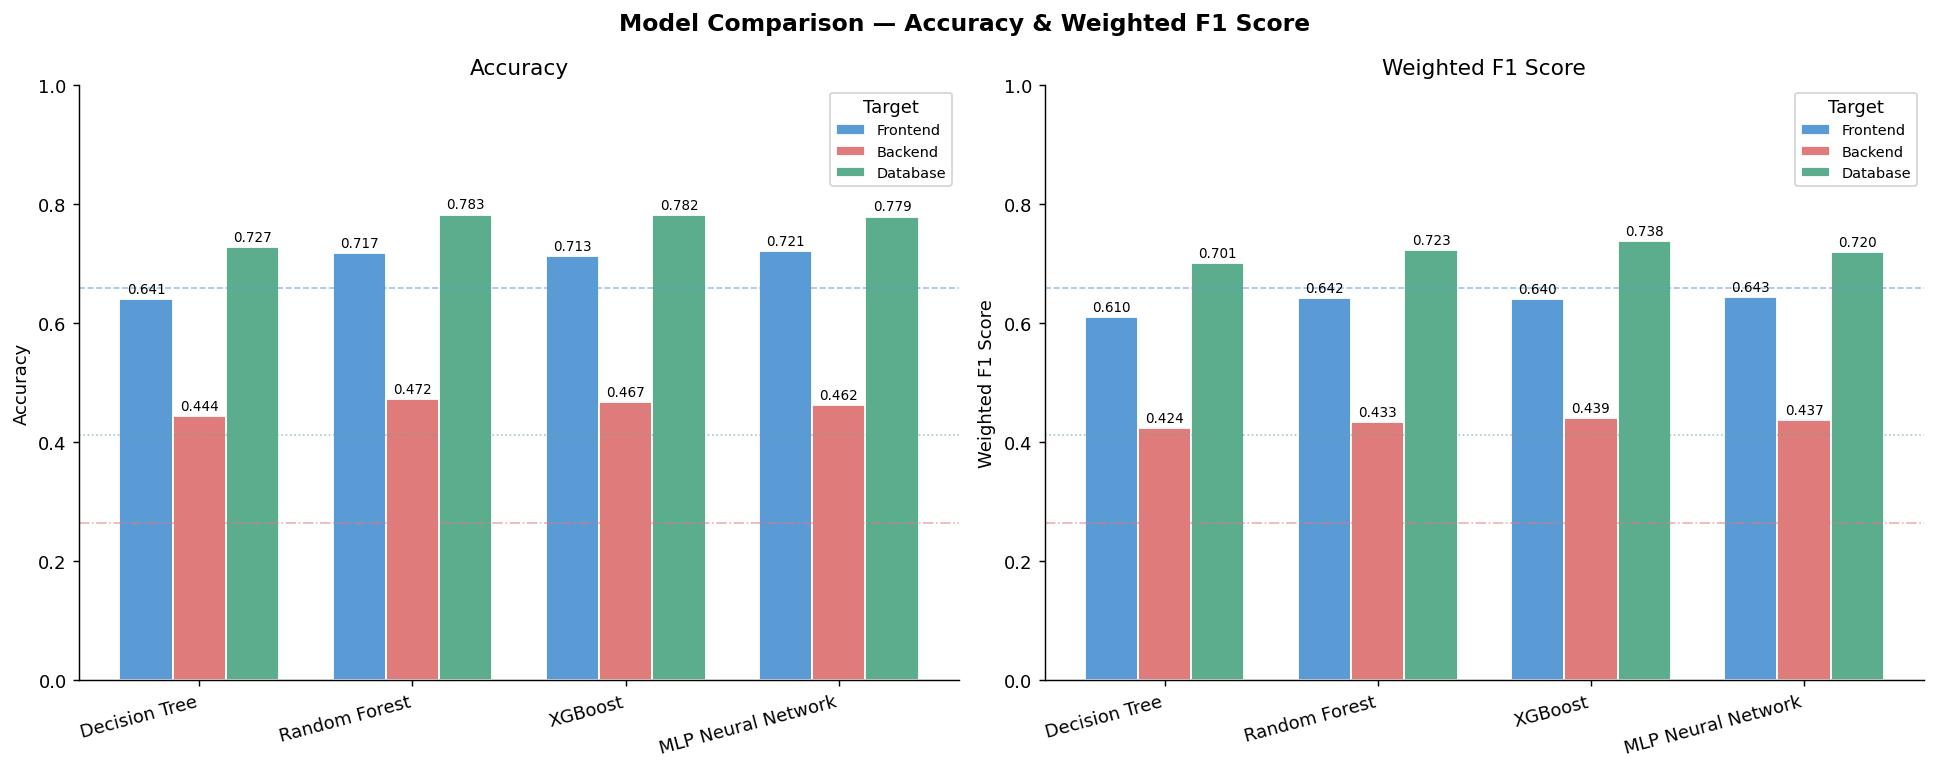

✓ Chart 1 saved → model_01_accuracy_v2.png


In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 8 ─ CHART 1: Accuracy & F1 comparison
# ══════════════════════════════════════════════════════════════
model_names = list(MODELS.keys())
targets     = ["Frontend","Backend","Database"]
colors      = ["#5B9BD5","#E07B7B","#5BAD8E"]
x           = np.arange(len(model_names))
width       = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Model Comparison — Accuracy & Weighted F1 Score ",
             fontsize=13, fontweight="bold")

baselines = {"Frontend":0.659, "Backend":0.263, "Database":0.411}

for ax, metric, ylabel, bl_label in zip(
    axes,
    ["accuracy","f1_weighted"],
    ["Accuracy","Weighted F1 Score"],
    ["Accuracy","F1"]
):
    for ti, (tname, color) in enumerate(zip(targets, colors)):
        vals = [results[m][tname][metric] for m in model_names]
        bars = ax.bar(x + (ti-1)*width, vals, width,
                      label=tname, color=color, edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.005, f"{v:.3f}",
                    ha="center", va="bottom", fontsize=7.5)

    for tname, color, ls in zip(targets, colors, ["--","-.",":"]):
        ax.axhline(y=baselines[tname], color=color,
                   linestyle=ls, linewidth=0.9, alpha=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha="right")
    ax.set_ylabel(ylabel); ax.set_title(ylabel)
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=8, title="Target")

plt.tight_layout()
plt.savefig("model_01_accuracy_v2.png", bbox_inches="tight")
plt.show()
print("✓ Chart 1 saved → model_01_accuracy_v2.png")

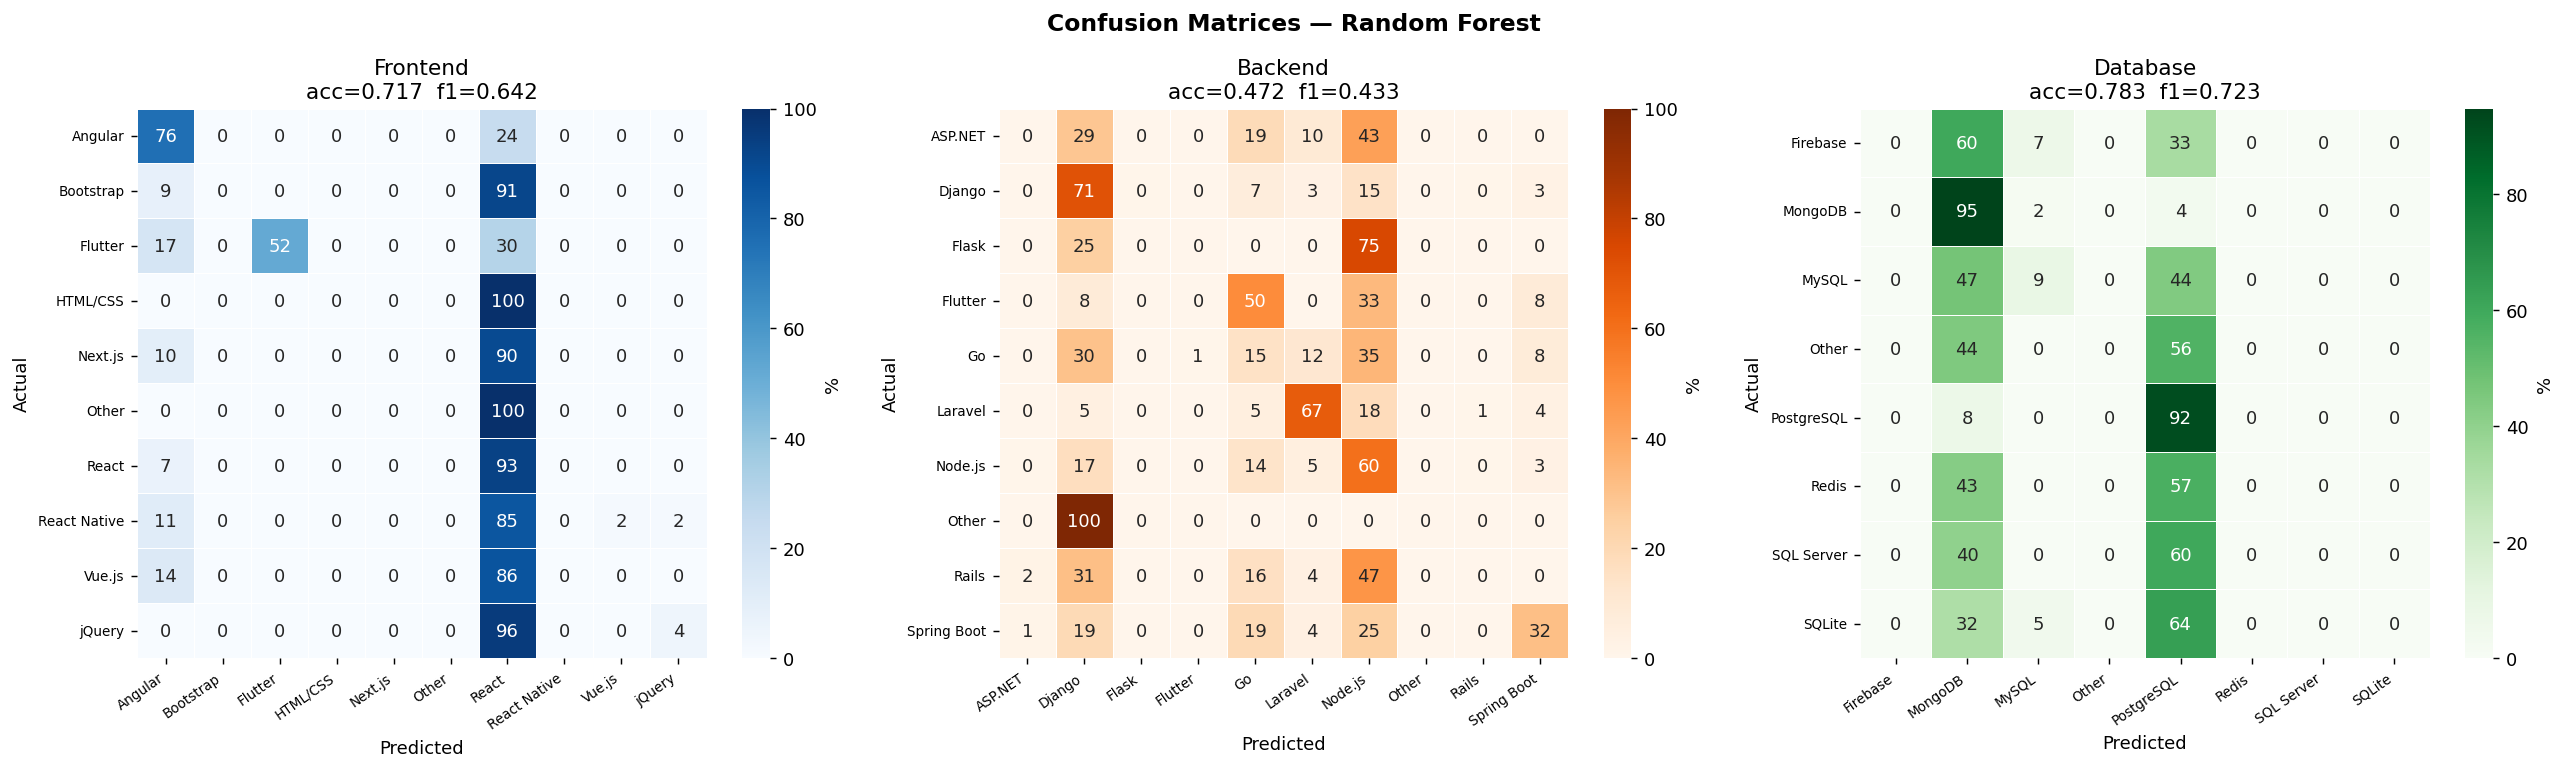

✓ Chart 2 saved → model_02_confusion_matrices_v2.png


In [11]:
# ══════════════════════════════════════════════════════════════
# CELL 9 ─ CHART 2: Confusion matrices (best model)
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f"Confusion Matrices — {best_name}",
             fontsize=13, fontweight="bold")

for ax, (tname, (_, y_test, le)), cmap in zip(
    axes, TARGETS.items(), ["Blues","Oranges","Greens"]
):
    y_pred = trained[best_name][tname].predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt=".0f", cmap=cmap,
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.4, linecolor="white",
                cbar_kws={"label":"%"}, ax=ax)
    acc = results[best_name][tname]["accuracy"]
    f1  = results[best_name][tname]["f1_weighted"]
    ax.set_title(f"{tname}\nacc={acc:.3f}  f1={f1:.3f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=7.5)
    plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=7.5)

plt.tight_layout()
plt.savefig("model_02_confusion_matrices_v2.png", bbox_inches="tight")
plt.show()
print("✓ Chart 2 saved → model_02_confusion_matrices_v2.png")

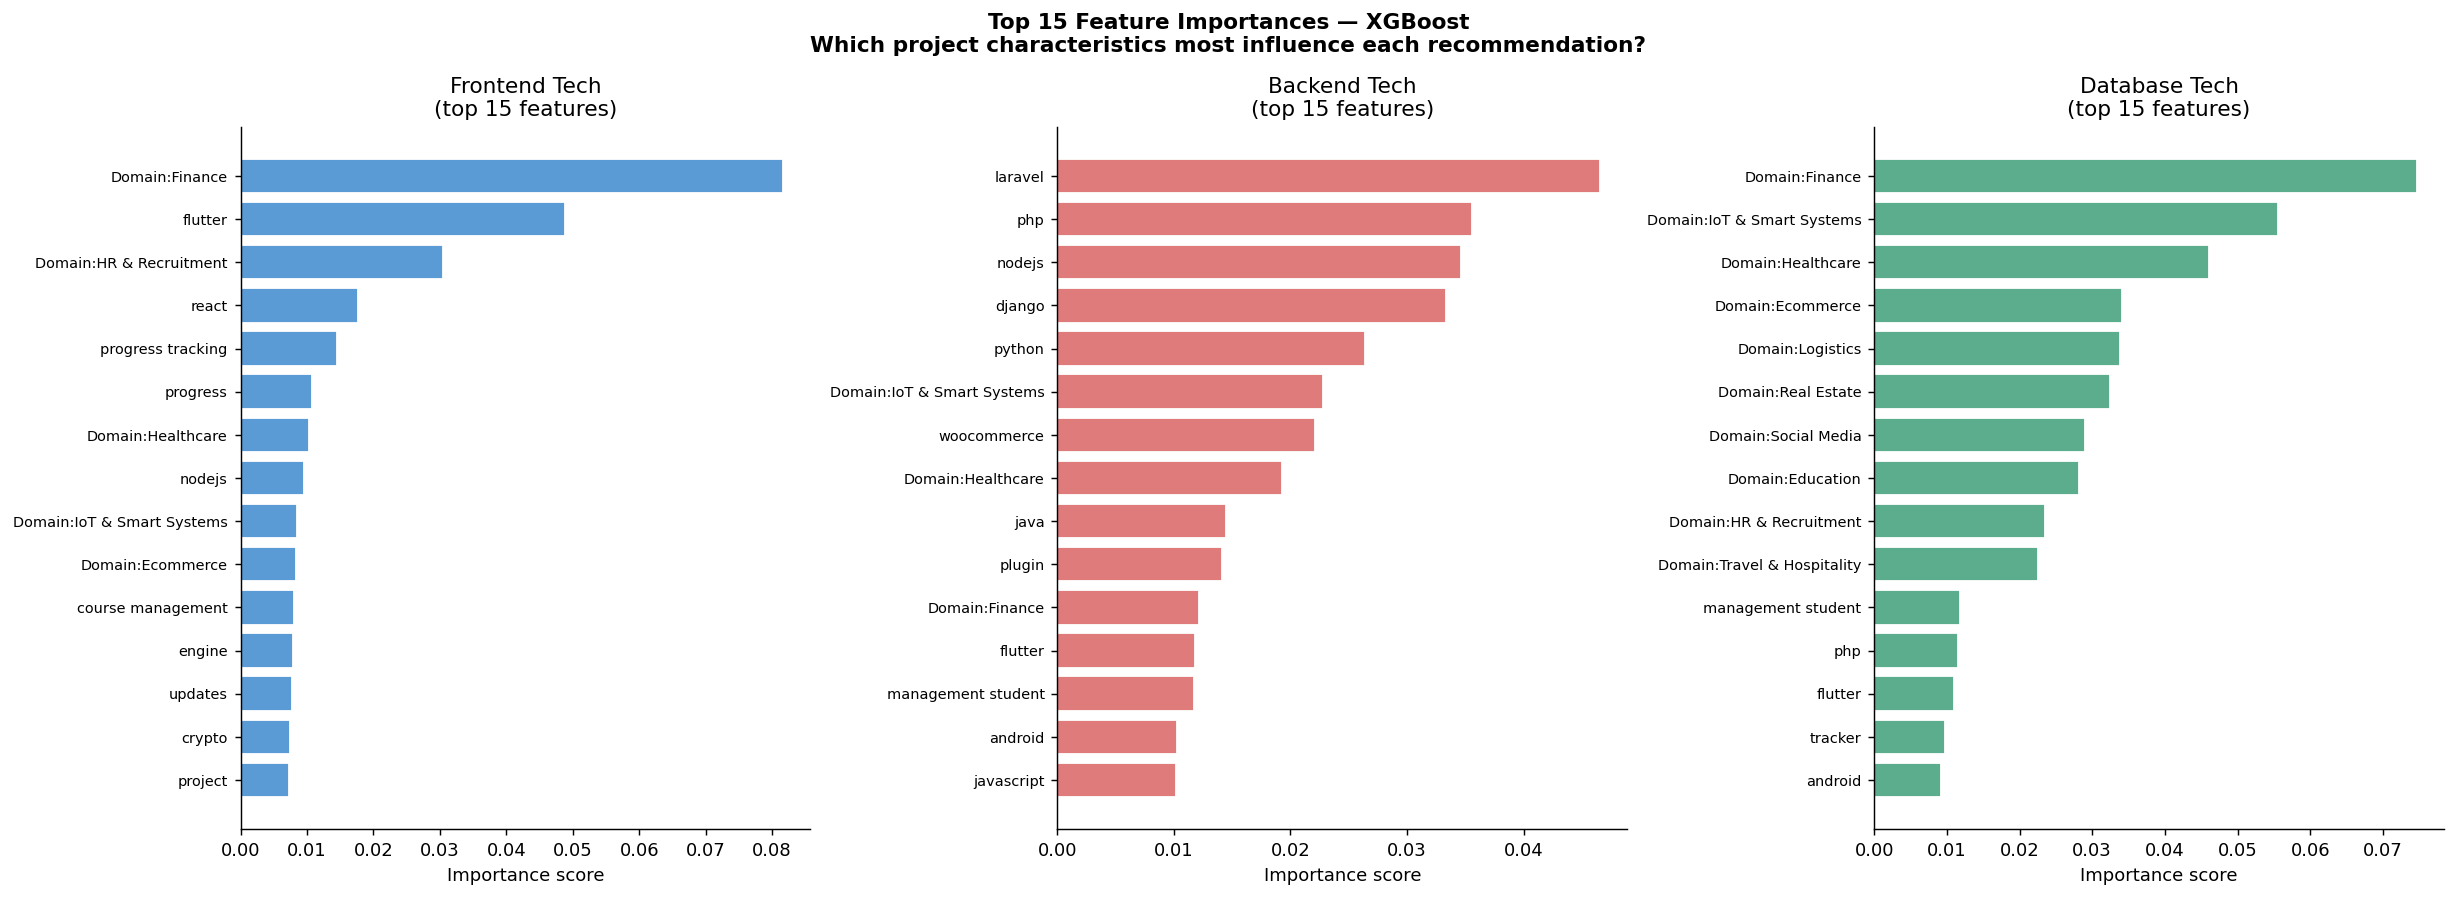

✓ Chart 3 saved → model_03_feature_importance_v2.png


In [12]:
# ══════════════════════════════════════════════════════════════
# CELL 10 ─ CHART 3: Feature importance (XGBoost)
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.suptitle("Top 15 Feature Importances — XGBoost\n"
             "Which project characteristics most influence each recommendation?",
             fontsize=12, fontweight="bold")

xgb_models = trained["XGBoost"]
feat_arr   = np.array(feat_names)
colors_fi  = ["#5B9BD5","#E07B7B","#5BAD8E"]

for ax, tname, color in zip(axes, ["Frontend","Backend","Database"], colors_fi):
    model   = xgb_models[tname]
    imp     = model.feature_importances_
    top_idx = np.argsort(imp)[::-1][:15]
    labels  = [feat_arr[i].replace("tfidf_","").replace("dom_","Domain:")
                          .replace("_enc","").replace("_"," ")
               for i in top_idx]
    ax.barh(range(15), imp[top_idx][::-1], color=color, edgecolor="white")
    ax.set_yticks(range(15))
    ax.set_yticklabels(labels[::-1], fontsize=8)
    ax.set_title(f"{tname} Tech\n(top 15 features)")
    ax.set_xlabel("Importance score")

plt.tight_layout()
plt.savefig("model_03_feature_importance_v2.png", bbox_inches="tight")
plt.show()
print("✓ Chart 3 saved → model_03_feature_importance_v2.png")


5-fold cross-validation (Frontend)...
  Decision Tree            0.639 ± 0.011
  Random Forest            0.687 ± 0.008
  XGBoost                  0.686 ± 0.016
  MLP Neural Network       0.688 ± 0.009


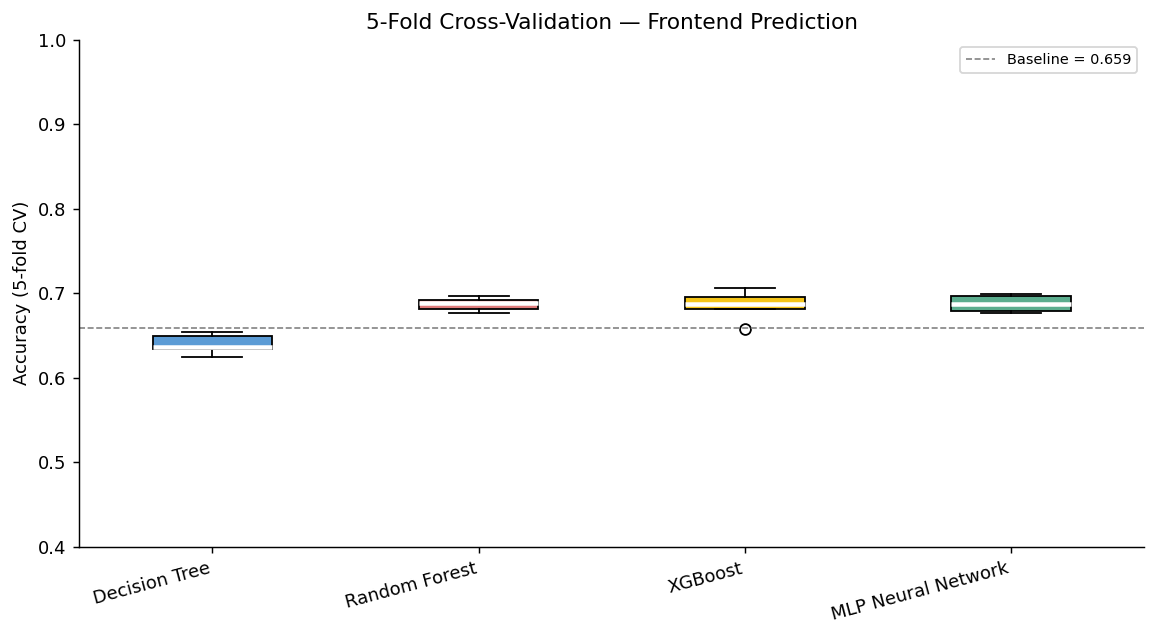

✓ Chart 4 saved → model_04_cross_validation_v2.png


In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 11 ─ CHART 4: Cross-validation (Frontend)
# ══════════════════════════════════════════════════════════════
print("\n5-fold cross-validation (Frontend)...")
cv_results = {}
for mname, model_template in MODELS.items():
    m = copy.deepcopy(model_template)
    scores = cross_val_score(m, X_train, y_fe_train,
                              cv=5, scoring="accuracy", n_jobs=-1)
    cv_results[mname] = scores
    print(f"  {mname:<24} {scores.mean():.3f} ± {scores.std():.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot([cv_results[m] for m in MODELS.keys()],
                patch_artist=True,
                medianprops={"color":"white","linewidth":2.5})
for patch, color in zip(bp["boxes"], ["#5B9BD5","#E07B7B","#F5C518","#5BAD8E"]):
    patch.set_facecolor(color)
ax.set_xticks(range(1, len(MODELS)+1))
ax.set_xticklabels(list(MODELS.keys()), rotation=15, ha="right")
ax.set_ylabel("Accuracy (5-fold CV)")
ax.set_title("5-Fold Cross-Validation — Frontend Prediction")
ax.axhline(y=0.659, color="gray", linestyle="--", linewidth=0.9,
           label="Baseline = 0.659")
ax.legend(fontsize=8); ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.savefig("model_04_cross_validation_v2.png", bbox_inches="tight")
plt.show()
print("✓ Chart 4 saved → model_04_cross_validation_v2.png")


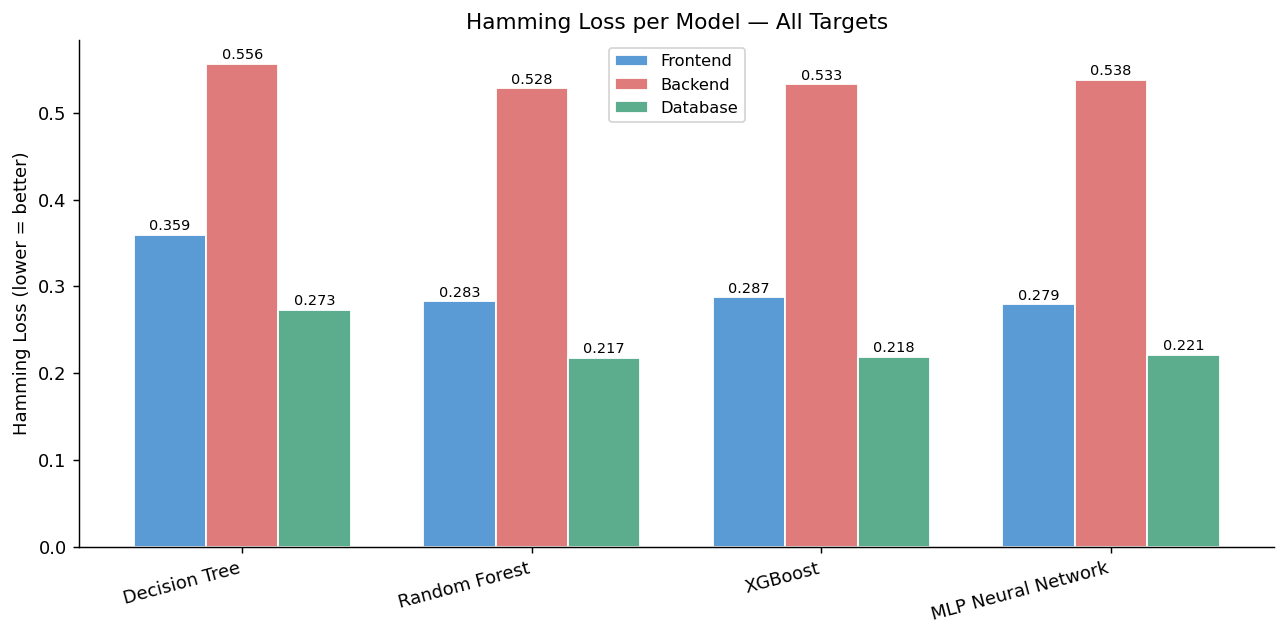

✓ Chart 5 saved → model_05_hamming_loss_v2.png


In [14]:
# ══════════════════════════════════════════════════════════════
# CELL 12 ─ CHART 5: Hamming loss
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(MODELS)); width = 0.25
for ti, (tname, color) in enumerate(zip(targets, colors)):
    vals = [results[m][tname]["hamming"] for m in model_names]
    bars = ax.bar(x+(ti-1)*width, vals, width,
                  label=tname, color=color, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.002, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylabel("Hamming Loss (lower = better)")
ax.set_title("Hamming Loss per Model — All Targets")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("model_05_hamming_loss_v2.png", bbox_inches="tight")
plt.show()
print("✓ Chart 5 saved → model_05_hamming_loss_v2.png")

In [15]:
# ══════════════════════════════════════════════════════════════
# CELL 13 ─ Save best model & all outputs
# ══════════════════════════════════════════════════════════════
joblib.dump({
    "model_name":   best_name,
    "frontend":     trained[best_name]["Frontend"],
    "backend":      trained[best_name]["Backend"],
    "database":     trained[best_name]["Database"],
    "le_fe":        le_fe,  "le_be": le_be, "le_db": le_db,
    "feat_names":   feat_names,
    "results":      results,
    "domain_cols":  list(domain_dummies.columns),
}, "best_model_v2.pkl")

joblib.dump(trained,  "all_trained_models_v2.pkl")
joblib.dump(results,  "all_results_v2.pkl")
joblib.dump(le_fe,    "label_encoder_frontend.pkl")
joblib.dump(le_be,    "label_encoder_backend.pkl")
joblib.dump(le_db,    "label_encoder_database.pkl")

print(f"✓ Best model saved → best_model_v2.pkl  [{best_name}]")

✓ Best model saved → best_model_v2.pkl  [Random Forest]


In [16]:
# ══════════════════════════════════════════════════════════════
# CELL 14 ─ Final summary
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  IMPROVED MODEL TRAINING — FINAL SUMMARY")
print("=" * 65)
print(f"\n  Dataset       : {len(df):,} rows × {X.shape[1]} features")
print(f"  Train / Test  : {X_train.shape[0]} / {X_test.shape[0]}")
print(f"\n  Results (v2 vs v1 comparison):")
print(f"  {'Model':<22} {'FE Acc':>8}  {'BE Acc':>8}  {'DB Acc':>8}")
print(f"  {'─'*54}")

v1 = {"Decision Tree":(0.211,0.240,0.516),
      "Random Forest":(0.636,0.381,0.739),
      "XGBoost":      (0.646,0.391,0.752),
      "MLP Neural Network":(0.665,0.391,0.768)}

for _, r in summary_df.iterrows():
    mname = r["Model"]
    v1_vals = v1.get(mname, (0,0,0))
    fe_diff = r["FE Acc"]-v1_vals[0]
    be_diff = r["BE Acc"]-v1_vals[1]
    db_diff = r["DB Acc"]-v1_vals[2]
    print(f"  {mname:<22} {r['FE Acc']:>6.3f} ({fe_diff:+.3f})"
          f"  {r['BE Acc']:>6.3f} ({be_diff:+.3f})"
          f"  {r['DB Acc']:>6.3f} ({db_diff:+.3f})")

print(f"\n  Best model    : {best_name}")
print(f"\n  Research answers:")
print(f"  RQ3 → Best ML technique  : {best_name}")
print(f"  RQ4 → Accuracy vs baseline:")
print(f"        Frontend: model={summary_df.iloc[0]['FE Acc']:.3f} vs baseline=0.659")
print(f"        Backend : model={summary_df.iloc[0]['BE Acc']:.3f} vs baseline=0.263")
print(f"        Database: model={summary_df.iloc[0]['DB Acc']:.3f} vs baseline=0.411")
print(f"  RQ5 → Feature importance shows Domain + TF-IDF keywords drive predictions")
print("=" * 65)


  IMPROVED MODEL TRAINING — FINAL SUMMARY

  Dataset       : 4,437 rows × 165 features
  Train / Test  : 3549 / 888

  Results (v2 vs v1 comparison):
  Model                    FE Acc    BE Acc    DB Acc
  ──────────────────────────────────────────────────────
  Random Forest           0.717 (+0.081)   0.472 (+0.091)   0.783 (+0.044)
  XGBoost                 0.713 (+0.067)   0.467 (+0.076)   0.782 (+0.030)
  MLP Neural Network      0.721 (+0.056)   0.462 (+0.071)   0.779 (+0.011)
  Decision Tree           0.641 (+0.430)   0.444 (+0.204)   0.727 (+0.211)

  Best model    : Random Forest

  Research answers:
  RQ3 → Best ML technique  : Random Forest
  RQ4 → Accuracy vs baseline:
        Frontend: model=0.717 vs baseline=0.659
        Backend : model=0.472 vs baseline=0.263
        Database: model=0.783 vs baseline=0.411
  RQ5 → Feature importance shows Domain + TF-IDF keywords drive predictions


In [17]:
# ══════════════════════════════════════════════════════════════
# CELL 15 ─ Download all outputs
# ══════════════════════════════════════════════════════════════
OUTPUT_FILES = [
    "best_model_v2.pkl",
    "all_trained_models_v2.pkl",
    "all_results_v2.pkl",
    "tfidf_vectorizer.pkl",
    "label_encoder_frontend.pkl",
    "label_encoder_backend.pkl",
    "label_encoder_database.pkl",
    "model_comparison_v2.csv",
    "model_01_accuracy_v2.png",
    "model_02_confusion_matrices_v2.png",
    "model_03_feature_importance_v2.png",
    "model_04_cross_validation_v2.png",
    "model_05_hamming_loss_v2.png",
]
for f in OUTPUT_FILES:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇ {f}")

print("\n✓ Done! Next: say 'Guide me through SHAP explainability'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ best_model_v2.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇ model_04_cross_validation_v2.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ model_05_hamming_loss_v2.png

✓ Done! Next: say 'Guide me through SHAP explainability'


In [18]:
# ══════════════════════════════════════════════════════════════
# CELL 15 ─ Download all outputs
# ══════════════════════════════════════════════════════════════
OUTPUT_FILES = [
    "model_05_hamming_loss_v2.png",
]
for f in OUTPUT_FILES:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇ {f}")

print("\n✓ Done! Next: say 'Guide me through SHAP explainability'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ model_05_hamming_loss_v2.png

✓ Done! Next: say 'Guide me through SHAP explainability'
